# Minimal Viable Hybrid Model Notebook (Logistic → Hybrid-NN)

This notebook provides a **fast, self-contained baseline** for a two-stage hybrid model:
- **Stage 1:** Multinomial Logistic Regression (probability outputs)
- **Stage 2:** Shallow Neural Network (MLP) trained on **[original features + Stage-1 probabilities]**

Designed for rapid iteration under tight time limits.

## Key choices
- **Leakage-safe:** preprocessing is fit **within each CV fold**.
- **FAST_MODE:** run 2-fold CV and fewer NN iterations for quick diagnostics.
- **Expired rule:** optionally force prediction to **NO** when `discharge_disposition_id == 11`.


In [1]:
# --- Settings ---
FAST_MODE = True   # set False only for final 10-fold reporting

if FAST_MODE:
    N_SPLITS = 2
    MLP_MAX_ITER = 80
    MLP_HIDDEN = (64, 32)
else:
    N_SPLITS = 10
    MLP_MAX_ITER = 250
    MLP_HIDDEN = (128, 64)

RANDOM_STATE = 42


## 1) Load data
Expected file: `clean_train_df.csv` （If file name differs, update the path below.）

**Assumptions**
- target column: `readmitted` with values `NO`, `>30`, `<30`
- column `discharge_disposition_id` exists (for expired rule)


In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "final_clean_train_df.csv"  # change if needed
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", len(df.columns))
df.head()


Shape: (91589, 180)
Columns: 180


,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490


## 2) Target encoding + expired mask
Class order is fixed to: `['<30', '>30', 'NO']`.
Expired rule: if `discharge_disposition_id == 11`, force prediction to **NO**.


In [4]:
TARGET_COL = "readmitted"
CLASS_ORDER = ["<30", ">30", "NO"]

assert TARGET_COL in df.columns, f"Missing target column: {TARGET_COL}"
df[TARGET_COL] = df[TARGET_COL].astype(str)

label_to_idx = {c:i for i,c in enumerate(CLASS_ORDER)}
y_idx = df[TARGET_COL].map(label_to_idx).astype(int).to_numpy()

EXPIRED_COL = "discharge_disposition_id_11"
expired_mask = None
if EXPIRED_COL in df.columns:
    expired_mask = (df[EXPIRED_COL].astype(int) == 1).to_numpy()
    print("Expired count:", int(expired_mask.sum()))
else:
    print(f"WARNING: {EXPIRED_COL} not found; expired rule disabled.")

print("Class counts:", np.bincount(y_idx))


Expired count: 1475
Class counts: [10245 31989 49355]


## 3) Feature matrix (robust default)
This keeps feature engineering minimal:
- one-hot encode categorical
- median/mode impute
- scale numeric

If you already have a curated matrix `X` in your main notebook, you can replace this section and directly set `X_df`.


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X_df = df.drop(columns=[TARGET_COL])

num_cols = X_df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_df.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))


Numeric cols: 186 Categorical cols: 0


## 4) Helper functions

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from scipy import sparse
import pandas as pd
import numpy as np

def apply_expired_rule(pred_idx, expired_mask, no_class_index=2):
    if expired_mask is None:
        return pred_idx
    pred_idx = pred_idx.copy()
    pred_idx[expired_mask] = no_class_index
    return pred_idx

from sklearn.metrics import f1_score, recall_score
import numpy as np

def metrics_summary(y_true, y_pred):
    lt30_idx = CLASS_ORDER.index("<30")

    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "recall_lt30": recall_score(
            y_true, y_pred,
            labels=[lt30_idx],
            average=None
        )[0]
    }



## *）Updated NN import

In [33]:
import numpy as np

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def set_seed(seed: int = 0):
    np.random.seed(seed)
    tf.random.set_seed(seed)


def build_mlp_keras(
    input_dim: int,
    num_classes: int,
    hidden_units=(256, 128, 64),
    activation="relu",
    dropout=0.3,
    batch_norm=True,
    l2=1e-4,
    optimizer="adamw",
    lr=3e-4,
):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    for u in hidden_units:
        x = layers.Dense(
            u,
            activation=None,
            kernel_regularizer=keras.regularizers.l2(l2) if (l2 and l2 > 0) else None,
        )(x)
        if batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
        if dropout and dropout > 0:
            x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)

    opt_name = str(optimizer).lower()
    if opt_name == "adamw":
        opt = keras.optimizers.AdamW(learning_rate=lr)
    elif opt_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy")
    return model


class KerasMLPWrapper:
    """
    Scikit-like wrapper:
    - fit(X, y_idx)
    - predict_proba(X)
    - predict(X)
    """

    def __init__(
        self,
        num_classes: int,
        hidden_units=(256, 128, 64),
        activation="relu",
        dropout=0.3,
        batch_norm=True,
        l2=1e-4,
        optimizer="adamw",
        lr=3e-4,
        batch_size=256,
        epochs=50,
        patience=6,
        seed=0,
        verbose=0,
    ):
        self.num_classes = num_classes
        self.hidden_units = hidden_units
        self.activation = activation
        self.dropout = dropout
        self.batch_norm = batch_norm
        self.l2 = l2
        self.optimizer = optimizer
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.seed = seed
        self.verbose = verbose
        self.model_ = None

    def fit(self, X, y_idx):
        set_seed(self.seed)

        X = np.asarray(X)
        y_idx = np.asarray(y_idx).astype(int)

        self.model_ = build_mlp_keras(
            input_dim=X.shape[1],
            num_classes=self.num_classes,
            hidden_units=self.hidden_units,
            activation=self.activation,
            dropout=self.dropout,
            batch_norm=self.batch_norm,
            l2=self.l2,
            optimizer=self.optimizer,
            lr=self.lr,
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=self.patience,
                restore_best_weights=True,
            )
        ]

        self.model_.fit(
            X,
            y_idx,
            validation_split=0.1,
            epochs=self.epochs,
            batch_size=self.batch_size,
            callbacks=callbacks,
            verbose=self.verbose,
        )
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        proba = self.model_.predict(X, verbose=0)
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)


## 5) Hybrid CV runner (Logistic → MLP on augmented features)
Leakage-safe: preprocess and Logistic are fit on the training portion of each fold only.
A fold-cache avoids recomputing Logistic probabilities when iterating on MLP settings.


In [34]:
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score


def apply_expired_rule(pred_idx, expired_mask, no_class_index=2):
    if expired_mask is None:
        return pred_idx
    pred_idx = np.asarray(pred_idx).copy()
    pred_idx[np.asarray(expired_mask, dtype=bool)] = no_class_index
    return pred_idx


def _to_dense_if_sparse(X):
    return X.toarray() if sparse.issparse(X) else X


class _KerasMLPWrapper:
    """Minimal sklearn-like wrapper for a Keras MLP classifier."""
    def __init__(
        self,
        num_classes: int,
        hidden_units=(256, 128, 64),
        activation="relu",
        dropout=0.30,
        batch_norm=True,
        l2=1e-4,
        optimizer="adamw",
        lr=3e-4,
        batch_size=256,
        epochs=50,
        patience=6,
        seed=42,
        verbose=0,
    ):
        self.num_classes = int(num_classes)
        self.hidden_units = tuple(hidden_units)
        self.activation = activation
        self.dropout = float(dropout)
        self.batch_norm = bool(batch_norm)
        self.l2 = float(l2)
        self.optimizer = str(optimizer).lower()
        self.lr = float(lr)
        self.batch_size = int(batch_size)
        self.epochs = int(epochs)
        self.patience = int(patience)
        self.seed = int(seed)
        self.verbose = int(verbose)
        self.model_ = None

    def _build(self, input_dim: int):
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers

        np.random.seed(self.seed)
        tf.random.set_seed(self.seed)

        inputs = keras.Input(shape=(input_dim,))
        x = inputs

        reg = keras.regularizers.l2(self.l2) if (self.l2 and self.l2 > 0) else None

        for u in self.hidden_units:
            x = layers.Dense(u, activation=None, kernel_regularizer=reg)(x)
            if self.batch_norm:
                x = layers.BatchNormalization()(x)
            x = layers.Activation(self.activation)(x)
            if self.dropout and self.dropout > 0:
                x = layers.Dropout(self.dropout)(x)

        outputs = layers.Dense(self.num_classes, activation="softmax")(x)
        model = keras.Model(inputs, outputs)

        if self.optimizer == "adamw":
            opt = keras.optimizers.AdamW(learning_rate=self.lr)
        elif self.optimizer == "adam":
            opt = keras.optimizers.Adam(learning_rate=self.lr)
        else:
            raise ValueError(f"Unsupported optimizer: {self.optimizer}")

        model.compile(optimizer=opt, loss="sparse_categorical_crossentropy")
        return model

    def fit(self, X, y_idx):
        from tensorflow import keras

        X = np.asarray(X)
        y_idx = np.asarray(y_idx).astype(int)

        self.model_ = self._build(input_dim=X.shape[1])

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=self.patience,
                restore_best_weights=True,
            )
        ]

        self.model_.fit(
            X,
            y_idx,
            validation_split=0.1,
            epochs=self.epochs,
            batch_size=self.batch_size,
            callbacks=callbacks,
            verbose=self.verbose,
        )
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        return self.model_.predict(X, verbose=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)
def proba_align(lr_model, X, all_classes):
    """
    Align predict_proba output to a fixed set of class indices.
    Prevents crashes when some folds are missing a class.
    """
    p = lr_model.predict_proba(X)  # shape: (n, k_present)
    out = np.zeros((X.shape[0], len(all_classes)), dtype=float)
    out[:, lr_model.classes_.astype(int)] = p
    return out


def run_cv_gated_hybrid(
    X_df, y_idx, preprocess,
    expired_mask=None,
    n_splits=N_SPLITS, random_state=42,
    threshold=0.45,
    lt30_label_index=0,
    no_label_index=2,
    use_cache=True,

    # --- Keras NN hyperparams ---
    use_keras_nn=True,
    nn_hidden_units=(256, 128, 64),
    nn_dropout=0.30,
    nn_batch_norm=True,
    nn_l2=1e-4,
    nn_optimizer="adamw",
    nn_lr=3e-4,
    nn_batch_size=256,
    nn_epochs=50,
    nn_patience=6,
    nn_verbose=0,
):
    """
    Stage 1: LogisticRegression -> probas + LR prediction
    Stage 2: NN on augmented features [X + LR_probs]
    Gate: if max(LR_prob) >= threshold use LR else use NN
    Then apply expired rule (force NO)
    """

    y_idx = np.asarray(y_idx).astype(int)
    ALL_CLASSES = np.arange(int(np.max(y_idx) + 1))
    N_CLASSES = len(ALL_CLASSES)

    if expired_mask is not None:
        expired_mask = np.asarray(expired_mask, dtype=bool)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_rows = []
    cache = {} if use_cache else None

    for fold, (tr, va) in enumerate(skf.split(X_df, y_idx), start=1):
        X_tr_df, X_va_df = X_df.iloc[tr], X_df.iloc[va]
        y_tr, y_va = y_idx[tr], y_idx[va]
        expired_va = expired_mask[va] if expired_mask is not None else None

        # preprocess per fold
        if use_cache and fold in cache:
            X_tr, X_va = cache[fold]
        else:
            X_tr = preprocess.fit_transform(X_tr_df)
            X_va = preprocess.transform(X_va_df)
            if use_cache:
                cache[fold] = (X_tr, X_va)

        # stage 1: LR (OOF probs)  
        from sklearn.base import clone

        base_lr = LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            random_state=random_state,
        )
        skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

        # (1) Generate OOF probs for training fold
        # n_classes = len(np.unique(y_tr))
        # int(np.max(y_idx) + 1)
        
        p_tr_oof = np.zeros((X_tr.shape[0], N_CLASSES), dtype=float)

        for tr_i, va_i in skf_inner.split(X_tr, y_tr):
            lr_inner = clone(base_lr)
            lr_inner.fit(X_tr[tr_i], y_tr[tr_i])
            p_tr_oof[va_i] = proba_align(lr_inner, X_tr[va_i], ALL_CLASSES)

            # p_tr_oof[va_i] = proba_align(lr_inner, X_tr[va_i], ALL_CLASSES)
            

        # (2) Fit LR on full training fold to predict validation fold
        lr = clone(base_lr)
        lr.fit(X_tr, y_tr)
        p_va = proba_align(lr, X_va, ALL_CLASSES)
        y_pred_lr = lr.predict(X_va)

        # -------------------------
        # augment features: [X + LR_probs]
        # -------------------------
        if sparse.issparse(X_tr):
            X_tr_h = sparse.hstack([X_tr, sparse.csr_matrix(p_tr_oof)], format="csr")
            X_va_h = sparse.hstack([X_va, sparse.csr_matrix(p_va)], format="csr")
        else:
            X_tr_h = np.hstack([X_tr, p_tr_oof])
            X_va_h = np.hstack([X_va, p_va])



      
        # stage 2: NN tuning with inner cv
                # -----------------------------------------
        # stage 2: NN tuning with INNER CV (strict)
        # -----------------------------------------
        if use_keras_nn:
            from sklearn.base import clone
        

            # tuning grid (keep / edit as needed)
            SEEDS = [0, 1, 2, 3, 4]
            CONFIGS = [
                dict(nn_hidden_units=(128, 64),     nn_lr=1e-3, nn_dropout=0.2),
                dict(nn_hidden_units=(256, 128),    nn_lr=3e-4, nn_dropout=0.3),
            ]

            # base LR used to generate probabilities inside inner CV
            base_lr_inner = LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                C=1.0,
                random_state=random_state,
            )
            def _lr_oof_train_and_val_probs(X_train, y_train, X_val, base_lr, oof_splits=3):
                skf_oof = StratifiedKFold(
                    n_splits=oof_splits, shuffle=True, random_state=random_state
                )
                p_train_oof = np.zeros((X_train.shape[0], N_CLASSES), dtype=float)

                for tr2, va2 in skf_oof.split(X_train, y_train):
                    lr2 = clone(base_lr)
                    lr2.fit(X_train[tr2], y_train[tr2])
                    p_train_oof[va2] = proba_align(lr2, X_train[va2], ALL_CLASSES)

                lr_full = clone(base_lr)
                lr_full.fit(X_train, y_train)
                p_val = proba_align(lr_full, X_val, ALL_CLASSES)
                return p_train_oof, p_val


            # inner CV for NN tuning
            skf_nn = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

            best_score = -1.0
            best_cfg = None
            best_seed = None

            for cfg in CONFIGS:
                for sd in SEEDS:
                    inner_scores = []

                    for tr_in_idx, va_in_idx in skf_nn.split(X_tr, y_tr):
                        X_tr_in = X_tr[tr_in_idx]
                        y_tr_in = y_tr[tr_in_idx]
                        X_va_in = X_tr[va_in_idx]
                        y_va_in = y_tr[va_in_idx]

                        # build LR probability features WITHOUT leakage for this inner fold
                        p_tr_in_oof, p_va_in = _lr_oof_train_and_val_probs(
                            X_tr_in, y_tr_in, X_va_in, base_lr_inner, oof_splits=3
                        )

                        # augment inner fold features
                        if sparse.issparse(X_tr_in):
                            X_tr_in_h = sparse.hstack(
                                [X_tr_in, sparse.csr_matrix(p_tr_in_oof)], format="csr"
                            )
                            X_va_in_h = sparse.hstack(
                                [X_va_in, sparse.csr_matrix(p_va_in)], format="csr"
                            )
                        else:
                            X_tr_in_h = np.hstack([X_tr_in, p_tr_in_oof])
                            X_va_in_h = np.hstack([X_va_in, p_va_in])

                        # train NN on inner-train, evaluate on inner-val
                        nn_tmp = _KerasMLPWrapper(
                            num_classes=N_CLASSES,  # outer fold classes
                            hidden_units=cfg["nn_hidden_units"],
                            activation="relu",
                            dropout=cfg["nn_dropout"],
                            batch_norm=nn_batch_norm,
                            l2=nn_l2,
                            optimizer=nn_optimizer,
                            lr=cfg["nn_lr"],
                            batch_size=nn_batch_size,
                            epochs=nn_epochs,
                            patience=nn_patience,
                            seed=sd,
                            verbose=0,
                        )

                        nn_tmp.fit(_to_dense_if_sparse(X_tr_in_h), y_tr_in)
                        pred_in = nn_tmp.predict(_to_dense_if_sparse(X_va_in_h))
                        inner_scores.append(f1_score(y_va_in, pred_in, average="macro"))

                    mean_score = float(np.mean(inner_scores))

                    if mean_score > best_score:
                        best_score = mean_score
                        best_cfg = cfg
                        best_seed = sd

            print(
                f"[Fold {fold:02d}] best INNER-CV macro-F1={best_score:.4f} "
                f"cfg={best_cfg} seed={best_seed}"
            )

            # refit final NN on FULL outer training fold using already-built X_tr_h
            nn_final = _KerasMLPWrapper(
                num_classes=N_CLASSES,
                hidden_units=best_cfg["nn_hidden_units"],
                activation="relu",
                dropout=best_cfg["nn_dropout"],
                batch_norm=nn_batch_norm,
                l2=nn_l2,
                optimizer=nn_optimizer,
                lr=best_cfg["nn_lr"],
                batch_size=nn_batch_size,
                epochs=nn_epochs,
                patience=nn_patience,
                seed=best_seed,
                verbose=nn_verbose,
            )
            nn_final.fit(_to_dense_if_sparse(X_tr_h), y_tr)

            # predictions on outer validation fold (for gating)
            y_pred_nn = nn_final.predict(_to_dense_if_sparse(X_va_h))

        else:
            raise ValueError("use_keras_nn=False not supported in this clean version.")

       

        # gating
        maxp = p_va.max(axis=1)
        use_nn = maxp < float(threshold)

        y_pred = np.asarray(y_pred_lr).copy()
        y_pred[use_nn] = y_pred_nn[use_nn]

        # expired rule
        y_pred = apply_expired_rule(y_pred, expired_va, no_class_index=no_label_index)

        # metrics
        macro = f1_score(y_va, y_pred, average="macro")
        weighted = f1_score(y_va, y_pred, average="weighted")
        recall_lt30 = recall_score(
            (y_va == lt30_label_index).astype(int),
            (y_pred == lt30_label_index).astype(int),
            zero_division=0,
        )

        row = {
            "fold": fold,
            "macro_f1": float(macro),
            "weighted_f1": float(weighted),
            "recall_lt30": float(recall_lt30),
            "gated_to_nn_frac": float(use_nn.mean()),
        }
        fold_rows.append(row)

        print(
            f"[Fold {fold:02d}] macro-F1={macro:.4f}  weighted-F1={weighted:.4f}  "
            f"recall_<30={recall_lt30:.4f}  NN_used={row['gated_to_nn_frac']*100:.1f}%"
        )

    dfm = pd.DataFrame(fold_rows)
    summary = dfm[["macro_f1", "weighted_f1", "recall_lt30", "gated_to_nn_frac"]].agg(["mean", "std"])
    return dfm, summary



### What is confidence: Confidence Estimation and Gating Strategy

Code used:

p_va = lr.predict_proba(X_va);
maxp = p_va.max(axis=1)


The confidence of the Logistic Regression (LR) model is quantified using its predicted class probabilities.
For each sample (x), LR produces a posterior probability vector
$$
p(y=c \mid x), \quad c \in {1, \dots, C}
$$
via the softmax function. The confidence score is defined as the maximum class probability:
$$
\text{confidence}(x) = \max_c p(y=c \mid x)
$$

This value reflects how strongly the LR model favors its most likely class. A high confidence score indicates that the sample lies far from the decision boundary, where the linear model is expected to be reliable. Conversely, low confidence scores typically correspond to samples near class boundaries or in regions with non-linear structure, where linear assumptions may break down.

A confidence-based gating mechanism is therefore applied. If the LR confidence exceeds a predefined threshold (\tau), the LR prediction is accepted directly. Otherwise, the sample is delegated to a neural network (MLP) with higher representational capacity:
$$
\hat{y}(x) =
\begin{cases}
\hat{y}*{LR}(x), & \text{if } \max_c p(y=c \mid x) \ge \tau \
\hat{y}*{MLP}(x), & \text{otherwise}
\end{cases}
$$

## 6) Run Hybrid (FAST_MODE recommended first)

In [35]:

# CLASS_ORDER = ["<30", ">30", "NO"]

lt30_idx = CLASS_ORDER.index("<30")
no_idx = CLASS_ORDER.index("NO")

gated_df, gated_summary = run_cv_gated_hybrid(
    X_df=X_df,
    y_idx=y_idx,
    preprocess=preprocess,
    expired_mask=expired_mask,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    threshold=0.45,
    lt30_label_index=lt30_idx,
    no_label_index=no_idx,
    use_cache=True,
)


gated_df, gated_summary


[Fold 01] best INNER-CV macro-F1=0.4292 cfg={'nn_hidden_units': (256, 128), 'nn_lr': 0.0003, 'nn_dropout': 0.3} seed=0
[Fold 01] macro-F1=0.4620  weighted-F1=0.5527  recall_<30=0.2838  NN_used=52.0%
[Fold 02] best INNER-CV macro-F1=0.4320 cfg={'nn_hidden_units': (256, 128), 'nn_lr': 0.0003, 'nn_dropout': 0.3} seed=2
[Fold 02] macro-F1=0.4656  weighted-F1=0.5580  recall_<30=0.2702  NN_used=52.5%


(   fold  macro_f1  weighted_f1  recall_lt30  gated_to_nn_frac
 0     1  0.462031     0.552705     0.283818           0.52010
 1     2  0.465585     0.558013     0.270207           0.52544,
       macro_f1  weighted_f1  recall_lt30  gated_to_nn_frac
 mean  0.463808     0.555359     0.277013          0.522770
 std   0.002513     0.003754     0.009625          0.003776)

### Testing threshold

In [36]:
RUN_THRESHOLD_TEST = False   # <<< Switch here

if RUN_THRESHOLD_TEST:
    for t in [0.35, 0.40, 0.45, 0.50]:
        print(f"\n=== threshold = {t} ===")
        df_t, summ_t = run_cv_gated_hybrid(
            X_df=X_df,
            y_idx=y_idx,
            preprocess=preprocess,
            expired_mask=expired_mask,
            n_splits=2, # matching full model just put: N_SPLITS, here 2 for quick test
            random_state=RANDOM_STATE,
            threshold=t,
            use_cache=True,
        )
        display(summ_t)
else:
    print("⚠️ Threshold testing skipped (RUN_THRESHOLD_TEST = False).")
    print("Using previously selected threshold = 0.45")


⚠️ Threshold testing skipped (RUN_THRESHOLD_TEST = False).
Using previously selected threshold = 0.45


In [37]:
## Thresholds summary diagram : Macro-F1 & Recall(<30) vs Threshold

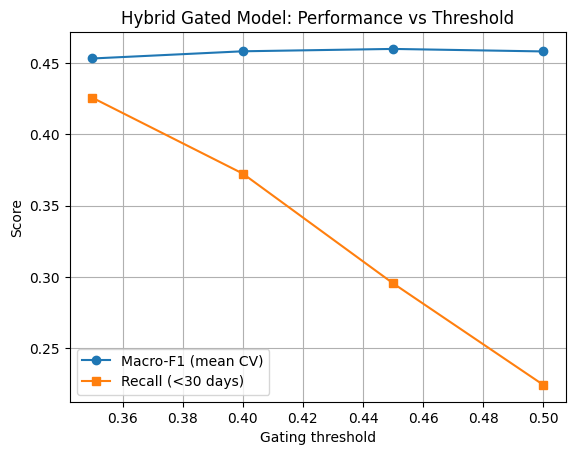

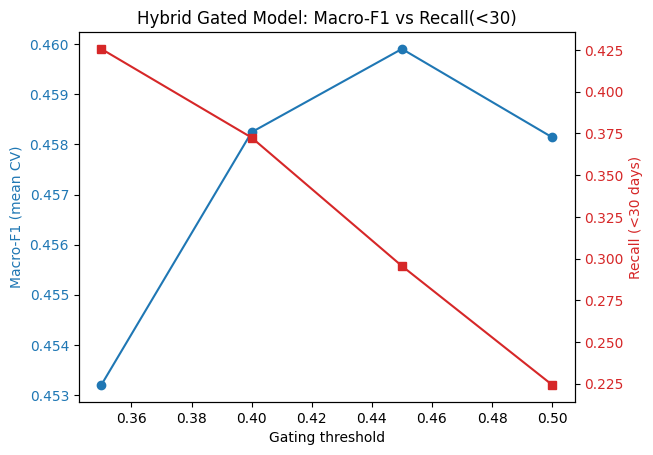

In [38]:
import matplotlib.pyplot as plt

thresholds = [0.35, 0.40, 0.45, 0.50]

macro_f1_means = [0.453199, 0.458244, 0.459906, 0.458141]
recall_lt30_means = [0.425636, 0.372472, 0.295499, 0.224234]

plt.figure()

plt.plot(thresholds, macro_f1_means, marker='o', label="Macro-F1 (mean CV)")
plt.plot(thresholds, recall_lt30_means, marker='s', label="Recall (<30 days)")

plt.xlabel("Gating threshold")
plt.ylabel("Score")
plt.title("Hybrid Gated Model: Performance vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

fig, ax1 = plt.subplots()

ax1.plot(thresholds, macro_f1_means, marker='o', color='tab:blue')
ax1.set_xlabel("Gating threshold")
ax1.set_ylabel("Macro-F1 (mean CV)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(thresholds, recall_lt30_means, marker='s', color='tab:red')
ax2.set_ylabel("Recall (<30 days)", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Hybrid Gated Model: Macro-F1 vs Recall(<30)")
plt.show()


## 7) For comparion - Linear baseline only (Logistic)
Run this to quantify whether Hybrid adds value beyond the linear model.


In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score

def run_cv_logistic_only(
    X_df, y_idx, preprocess, expired_mask=None,
    n_splits=10, random_state=42,
    lt30_label_index=0,      # <30 label index
    no_label_index=2         # NO label index（for expired rule）
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for fold, (tr, va) in enumerate(skf.split(X_df, y_idx), start=1):
        X_tr_df, X_va_df = X_df.iloc[tr], X_df.iloc[va]
        y_tr, y_va = y_idx[tr], y_idx[va]
        expired_va = expired_mask[va] if expired_mask is not None else None

        # preprocess (no leakage)
        X_tr = preprocess.fit_transform(X_tr_df)
        X_va = preprocess.transform(X_va_df)

        # logistic regression
        lr = LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            class_weight="balanced",
            C=1.0
        )
        lr.fit(X_tr, y_tr)
        y_pred = lr.predict(X_va)

        # expired rule -> force NO
        if expired_va is not None:
            y_pred = y_pred.copy()
            y_pred[expired_va] = no_label_index

        # metrics
        macro = f1_score(y_va, y_pred, average="macro")
        weighted = f1_score(y_va, y_pred, average="weighted")
        recall_lt30 = recall_score(
            y_va, y_pred,
            labels=[lt30_label_index],
            average=None
        )[0]

        rows.append({
            "fold": fold,
            "macro_f1": macro,
            "weighted_f1": weighted,
            "recall_lt30": recall_lt30
        })

        print(
            f"[Fold {fold:02d}] "
            f"macro-F1={macro:.4f}  "
            f"weighted-F1={weighted:.4f}  "
            f"recall_<30={recall_lt30:.4f}"
        )

    dfm = pd.DataFrame(rows)
    summary = dfm[["macro_f1","weighted_f1","recall_lt30"]].agg(["mean","std"])
    return dfm, summary

lt30_idx = CLASS_ORDER.index("<30")
no_idx = CLASS_ORDER.index("NO")

lin_df, lin_summary = run_cv_logistic_only(
    X_df=X_df,
    y_idx=y_idx,
    preprocess=preprocess,
    expired_mask=expired_mask,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    lt30_label_index=lt30_idx,
    no_label_index=no_idx
)

lin_df, lin_summary


[Fold 01] macro-F1=0.4451  weighted-F1=0.5218  recall_<30=0.4259
[Fold 02] macro-F1=0.4488  weighted-F1=0.5291  recall_<30=0.4024


(   fold  macro_f1  weighted_f1  recall_lt30
 0     1  0.445108     0.521814     0.425922
 1     2  0.448813     0.529062     0.402382,
       macro_f1  weighted_f1  recall_lt30
 mean  0.446961     0.525438     0.414152
 std   0.002620     0.005125     0.016646)

## 8) Reporting notes
- Motivation: linear models are strong and stable, but minority performance remains challenging.
- Hybrid: logistic probabilities act as a **global prior**, NN learns **residual patterns**.
- Leakage control: all preprocessing and Stage-1 fitting are performed within each fold.
- Efficiency: FAST_MODE for development; run full 10-fold once for the final configuration.
